# eClipseBord - EDA
A short exploration of the solar eclipse dataset (Shape to check the number of rows and columns)

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# The dataset lives in the shared data/ folder at the project root.
df = pd.read_csv("../data/solar.csv")
df.shape

(11898, 15)

# Exlore the columns in the dataset

In [2]:
df.head()

,Catalog Number,Calendar Date,Eclipse Time,Delta T (s),Lunation Number,Saros Number,Eclipse Type,Gamma,Eclipse Magnitude,Latitude,Longitude,Sun Altitude,Sun Azimuth,Path Width (km),Central Duration
0,1,-1999 June 12,03:14:51,46438,-49456,5,T,-0.2701,1.0733,6.0N,33.3W,74,344,247,06m37s
1,2,-1999 December 5,23:45:23,46426,-49450,10,A,-0.2317,0.9382,32.9S,10.8E,76,21,236,06m44s
2,3,-1998 June 1,18:09:16,46415,-49444,15,T,0.4994,1.0284,46.2N,83.4E,60,151,111,02m15s
3,4,-1998 November 25,05:57:03,46403,-49438,20,A,-0.9045,0.9806,67.8S,143.8W,25,74,162,01m14s
4,5,-1997 April 22,13:19:56,46393,-49433,-13,P,-1.4670,0.1611,60.6S,106.4W,0,281,NaN,NaN


# Column names and data types.

In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 11898 entries, 0 to 11897
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Catalog Number     11898 non-null  int64  
 1   Calendar Date      11898 non-null  str    
 2   Eclipse Time       11898 non-null  str    
 3   Delta T (s)        11898 non-null  int64  
 4   Lunation Number    11898 non-null  int64  
 5   Saros Number       11898 non-null  int64  
 6   Eclipse Type       11898 non-null  str    
 7   Gamma              11898 non-null  float64
 8   Eclipse Magnitude  11898 non-null  float64
 9   Latitude           11898 non-null  str    
 10  Longitude          11898 non-null  str    
 11  Sun Altitude       11898 non-null  int64  
 12  Sun Azimuth        11898 non-null  int64  
 13  Path Width (km)    7698 non-null   str    
 14  Central Duration   7698 non-null   str    
dtypes: float64(2), int64(6), str(7)
memory usage: 1.4 MB


## Eclipse types
The 'Eclipse Type' column uses letter codes. The first letter is the main type:
P = Partial, A = Annular, T = Total, H = Hybrid.

In [5]:
type_names = {"P": "Partial", "A": "Annular", "T": "Total", "H": "Hybrid"}
df["type_name"] = df["Eclipse Type"].str[0].map(type_names).fillna("Other")

type_counts = df["type_name"].value_counts()
type_counts

type_name
Partial    4200
Annular    3956
Total      3173
Hybrid      569
Name: count, dtype: int64

## bar chart of how many eclipses there are of each type.

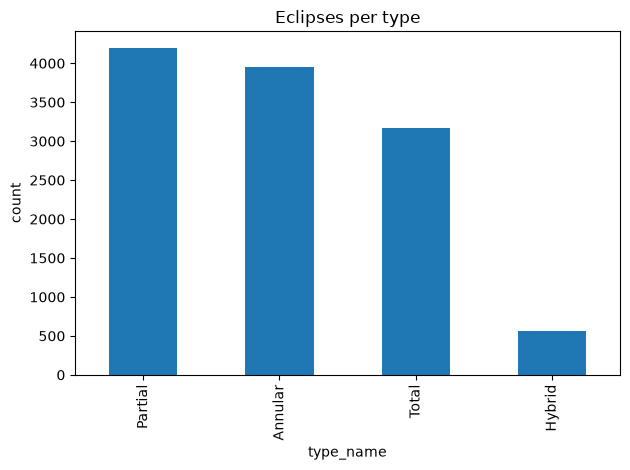

In [6]:
type_counts.plot(kind="bar", title="Eclipses per type")
plt.ylabel("count")
plt.tight_layout()
plt.show()

## Eclipse magnitude
How strong are the eclipses? distribution of 'Eclipse Magnitude'.

In [7]:
df["Eclipse Magnitude"].describe()

count    11898.000000
mean         0.812748
std          0.300398
min          0.000000
25%          0.675925
50%          0.950600
75%          1.018400
max          1.081300
Name: Eclipse Magnitude, dtype: float64

## bar chart for eclipse magnitude distribution 

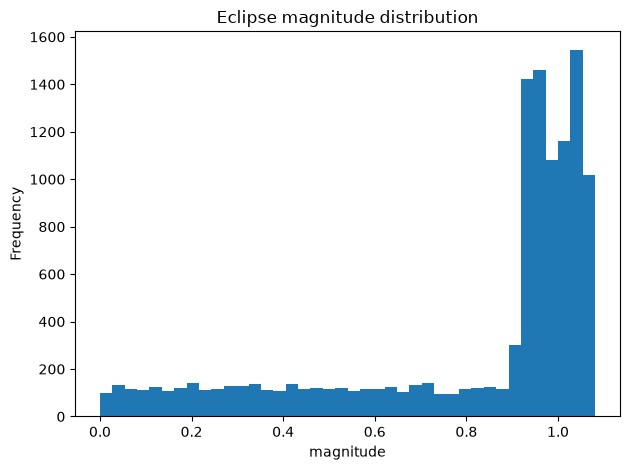

In [8]:
df["Eclipse Magnitude"].plot(kind="hist", bins=40, title="Eclipse magnitude distribution")
plt.xlabel("magnitude")
plt.tight_layout()
plt.show()

## Time span
The 'Calendar Date' starts with the year (which can be negative for BCE). Parsing it to see the range.

In [9]:
df["year"] = df["Calendar Date"].str.split().str[0].astype(int)
print("First year:", df["year"].min())
print("Last year:", df["year"].max())

First year: -1999
Last year: 3000
